# Import

In [1]:
import time
from time import sleep, monotonic
import datetime
import numpy as np
import matplotlib.pyplot as plt
import sys
import pyvisa
import qcodes as qc
from qcodes.dataset import Measurement
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
from qcodes.station import Station
initialise_or_create_database_at("./2026-04-17_SNSPD8.db")
from functions import quick_check
from functions import calibrate
import snspd
params = snspd.snspd('D:\SNSPD\SNSPD2\SNSPD5\snspd8-1.yaml')

# Set up experiment
exp_name = 'SNSPD8'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

<>:20: SyntaxWarning: invalid escape sequence '\S'
<>:20: SyntaxWarning: invalid escape sequence '\S'
C:\Users\QNL\AppData\Local\Temp\ipykernel_42668\642165314.py:20: SyntaxWarning: invalid escape sequence '\S'
  params = snspd.snspd('D:\SNSPD\SNSPD2\SNSPD5\snspd8-1.yaml')


Logging hadn't been started.
Activating auto-logging. Current session state plus future input saved.
Filename       : C:\Users\QNL\.qcodes\logs\command_history.log
Mode           : append
Output logging : True
Raw input log  : False
Timestamping   : True
State          : active
Qcodes Logfile : C:\Users\QNL\.qcodes\logs\260428-42668-qcodes.log
Experiment loaded. Last ID no: 9


In [2]:
station = Station(config_file="friesland.yaml")

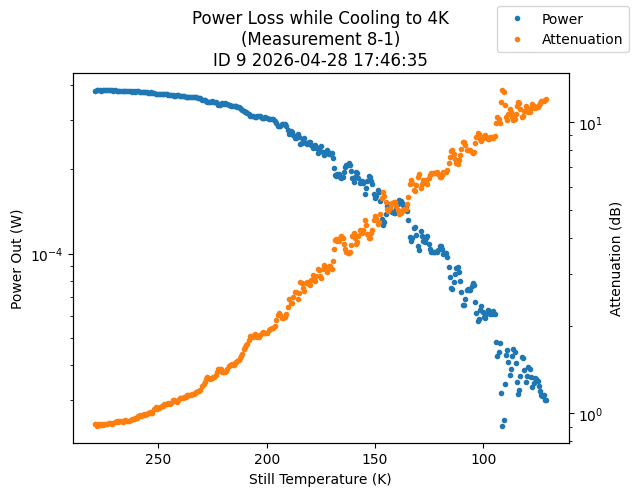

In [13]:
ID = 9
data = load_by_id(ID).get_parameter_data()
power10 = data['power10']['power10']
power90 = data['power90']['power90']
attenuation = data['attenuation']['attenuation']
still_temp = data['still_temp']['still_temp']

fig, ax1 = plt.subplots()

ax1.semilogy(still_temp, power10, '.', label='Power')
ax1.set_xlabel('Still Temperature (K)')
ax1.set_ylabel('Power Out (W)')
ax1.set_title(params.make_title('Power Loss while Cooling to 4K\n(Measurement 8-1)', ID))
ax1.invert_xaxis()

ax2 = ax1.twinx()
ax2.semilogy(still_temp, attenuation, '.', color='tab:orange', label='Attenuation') 
ax2.set_xlabel('Still Temperature (K)')
ax2.set_ylabel('Attenuation (dB)')
fig.legend()


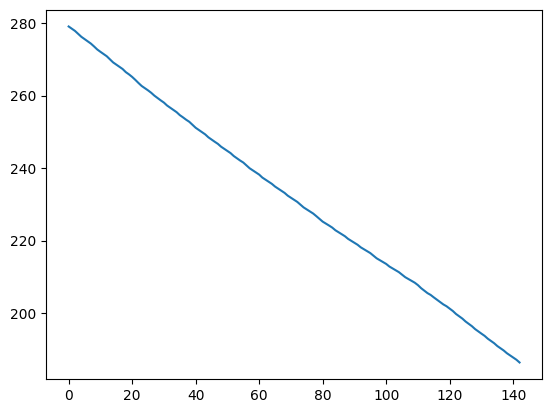

In [10]:
plt.plot(still_temp)

# OLD

Through optical breakout

In [11]:
ID = 1 
data = load_by_id(ID).get_parameter_data()
power10 = data['power10']['power10']
power90 = data['power90']['power90']
attenuation = data['attenuation']['attenuation']

print(f'Power90: {power90[0]}') 
print(f'Power10: {power10[0]}')
print(f'Atttenuation: {attenuation[0]}')

Power90: 0.00488496805
Power10: 0.000297434075
Atttenuation: 2.00997306148436


Through feedthrough

In [12]:
for ID in range(2, 5):
    data = load_by_id(ID).get_parameter_data()
    power10 = data['power10']['power10']
    power90 = data['power90']['power90']
    attenuation = data['attenuation']['attenuation']
    
    print(f'Power90: {power90[0]}') 
    print(f'Power10: {power10[0]}')
    print(f'Atttenuation: {attenuation[0]}')

Power90: 0.00489019789
Power10: 0.000384206738
Atttenuation: 0.902877567037519
Power90: 0.00484941667
Power10: 0.000381087535
Atttenuation: 0.901910571485299
Power90: 0.00485778181
Power10: 0.000381557213
Atttenuation: 0.904046361853094


Cooling with Feedthrough

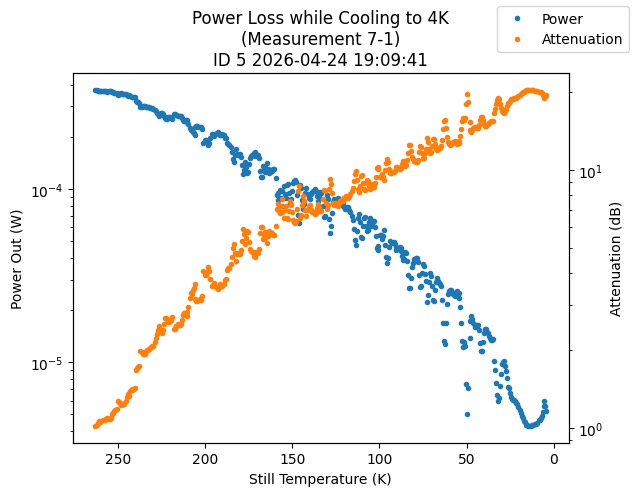

In [47]:
ID = 5
data = load_by_id(ID).get_parameter_data()
power10 = data['power10']['power10']
power90 = data['power90']['power90']
attenuation = data['attenuation']['attenuation']
still_temp = data['still_temp']['still_temp']

fig, ax1 = plt.subplots()

ax1.semilogy(still_temp, power10, '.', label='Power')
ax1.set_xlabel('Still Temperature (K)')
ax1.set_ylabel('Power Out (W)')
ax1.set_title(params.make_title('Power Loss while Cooling to 4K\n(Measurement 7-1)', ID))
ax1.invert_xaxis()

ax2 = ax1.twinx()
ax2.semilogy(still_temp, attenuation, '.', color='tab:orange', label='Attenuation') 
ax2.set_xlabel('Still Temperature (K)')
ax2.set_ylabel('Attenuation (dB)')
fig.legend()


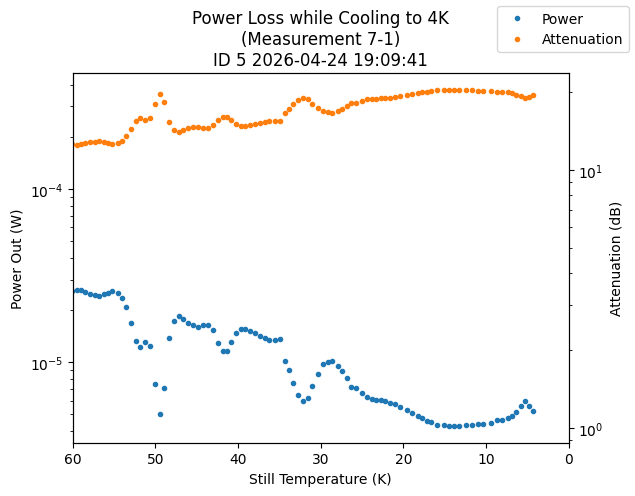

In [48]:
ID = 5
data = load_by_id(ID).get_parameter_data()
power10 = data['power10']['power10']
power90 = data['power90']['power90']
attenuation = data['attenuation']['attenuation']
still_temp = data['still_temp']['still_temp']

fig, ax1 = plt.subplots()

ax1.semilogy(still_temp, power10, '.', label='Power')
ax1.set_xlabel('Still Temperature (K)')
ax1.set_ylabel('Power Out (W)')
ax1.set_title(params.make_title('Power Loss while Cooling to 4K\n(Measurement 7-1)', ID))
ax1.set_xlim([0, 60])
ax1.invert_xaxis()

ax2 = ax1.twinx()
ax2.semilogy(still_temp, attenuation, '.', color='tab:orange', label='Attenuation') 
ax2.set_xlabel('Still Temperature (K)')
ax2.set_ylabel('Attenuation (dB)')
fig.legend()


At 4K 

In [52]:
for ID in range(6, 9):
    data = load_by_id(ID).get_parameter_data()
    power10 = data['power10']['power10']
    power90 = data['power90']['power90']
    attenuation = data['attenuation']['attenuation']
    
    print(f'Power90: {power90[0]}') 
    print(f'Power10: {power10[0]}')
    print(f'Atttenuation: {attenuation[0]}')

Power90: 0.00487660291
Power10: 5.15432885e-06
Atttenuation: 19.6147156984979
Power90: 0.00487451162
Power10: 5.20487492e-06
Atttenuation: 19.5704711248579
Power90: 0.00486928364
Power10: 5.20051117e-06
Atttenuation: 19.569453395722


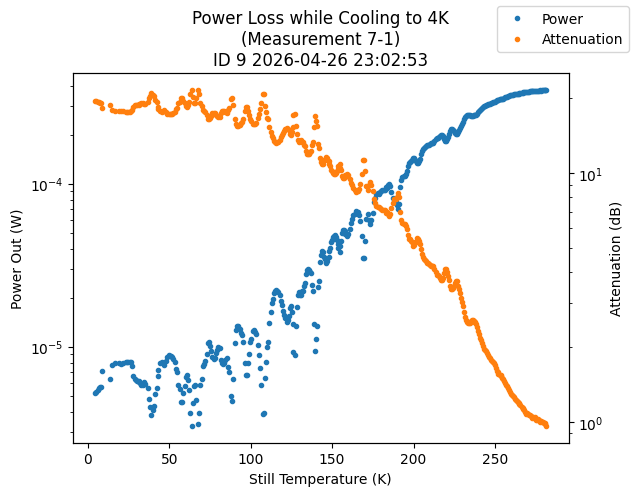

In [53]:
ID = 9
data = load_by_id(ID).get_parameter_data()
power10 = data['power10']['power10']
power90 = data['power90']['power90']
attenuation = data['attenuation']['attenuation']
still_temp = data['still_temp']['still_temp']

fig, ax1 = plt.subplots()

ax1.semilogy(still_temp, power10, '.', label='Power')
ax1.set_xlabel('Still Temperature (K)')
ax1.set_ylabel('Power Out (W)')
ax1.set_title(params.make_title('Power Loss while Cooling to 4K\n(Measurement 7-1)', ID))

ax2 = ax1.twinx()
ax2.semilogy(still_temp, attenuation, '.', color='tab:orange', label='Attenuation') 
ax2.set_xlabel('Still Temperature (K)')
ax2.set_ylabel('Attenuation (dB)')
fig.legend()
